In [25]:
import numpy as np
import matplotlib.pyplot as plt
import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 1 - PET/Code/Methods.py'>

In [34]:
def get_transmission_efficiency(
    source_x,          # The current position of the moving source (mm)
    slit_width_W,      # The gap between the lead plates (mm)
    attenuation_len,   # Lambda for the material (mm)
    n_rays=300000       # Number of MC rays to cast
):
    """
    Calculates the fraction of rays from a point source at (source_x, 0, 0)
    that hit the scintillator, accounting for attenuation through the lead gates.
    """

    # --- Constants from your setup ---
    Z_source = 0.0
    Z_gate_start = 36.0
    Z_gate_end = 46.0  # 36 + 10mm thickness
    Z_scint = 50.0
    R_scint = 35.0     # Scintillator radius

    # --- 1. Generate Isotropic Rays in 3D ---
    # We only care about forward rays (0 < theta < pi/2)
    # Uniform sphere sampling:
    phi = np.random.uniform(0, 2*np.pi, n_rays)
    costheta = np.random.uniform(0, 1, n_rays) # 0 to 1 for forward hemisphere
    sintheta = np.sqrt(1 - costheta**2)

    # Ray Unit Vectors (ux, uy, uz)
    ux = sintheta * np.cos(phi)
    uy = sintheta * np.sin(phi)
    uz = costheta

    # --- 2. Geometric Cut: Check if they hit the Scintillator ---
    # Project ray to Z_scint plane
    # t_scint is the distance scalar such that source + t*u = scint_pos
    # Since source is at Z=0: t_scint * uz = Z_scint => t_scint = Z_scint / uz

    # Position at scintillator plane
    # x(z) = source_x + (z / uz) * ux
    # y(z) = 0        + (z / uz) * uy

    # Scale factor mapping Z-distance to transverse distance
    scale_scint = Z_scint / uz
    x_at_scint = source_x + scale_scint * ux
    y_at_scint = scale_scint * uy

    # Check intersection with Scintillator Disk
    hit_mask = (x_at_scint**2 + y_at_scint**2) <= R_scint**2

    # Optimization: Filter out rays that miss the detector entirely
    # We only process the 'hits' to save computation
    ux = ux[hit_mask]
    uy = uy[hit_mask]
    uz = uz[hit_mask]
    num_hits = len(uz)

    if num_hits == 0:
        return 0.0

    # --- 3. Calculate Path Length Through Lead ---
    # The gates are defined by:
    #   Z range: [Z_gate_start, Z_gate_end]
    #   X range: |x| > W/2  (Lead exists outside the gap)

    # We need to find the Z-coordinates where the ray crosses the planes x = W/2 and x = -W/2
    # x(z) = source_x + z * (ux/uz)
    # Let slope m = ux/uz
    # x(z) = source_x + z * m
    # z_cross = (target_x - source_x) / m

    m = ux / uz

    # Avoid division by zero for rays perfectly vertical (uz ~ 1, ux ~ 0)
    # If m is tiny, the ray never crosses x-boundaries within reasonable Z
    # We set m to effectively infinity or epsilon logic
    m = np.where(np.abs(m) < 1e-9, 1e-9, m)

    # Calculate Z where ray enters/exits the "Hole" region (-W/2 to W/2)
    z_cross_left  = (-slit_width_W/2.0 - source_x) / m
    z_cross_right = ( slit_width_W/2.0 - source_x) / m

    # Determine the Z-interval where the ray is INSIDE the gap (Air)
    # Since we don't know if slope is positive or negative, we sort min/max
    z_gap_1 = np.minimum(z_cross_left, z_cross_right)
    z_gap_2 = np.maximum(z_cross_left, z_cross_right)

    # The ray is in AIR (Gap) when z is between [z_gap_1, z_gap_2]
    # The ray is in LEAD when z is NOT in that range (but still within 36-46)

    # We intersect the "Air Interval" [z_gap_1, z_gap_2] with the "Gate Interval" [36, 46]
    air_start = np.maximum(z_gap_1, Z_gate_start)
    air_end   = np.minimum(z_gap_2, Z_gate_end)

    # Length of Z spent in air (clamped to 0 if no overlap)
    z_len_air = np.maximum(0.0, air_end - air_start)

    # Total Z-length of the gate
    total_gate_z = Z_gate_end - Z_gate_start

    # Length of Z spent in lead
    z_len_lead = total_gate_z - z_len_air

    # --- 4. Convert Z-distance to True Path Distance ---
    # d = z / cos(theta) = z / uz
    d_lead = z_len_lead / uz

    # --- 5. Attenuation Sum ---
    # Weight of each ray = exp(-d / lambda)
    weights = np.exp(-d_lead / attenuation_len)

    # Sum weights and normalize by TOTAL original rays (n_rays)
    # (Because rays that missed the scintillator count as weight=0)
    total_detected_weight = np.sum(weights)

    detected_proportion = total_detected_weight / n_rays

    return detected_proportion

In [44]:
# --- usage ---

# Example: Scan the source position
x_scan = np.linspace(-40, 40, 200)
transmission = []

for x in x_scan:
    # 3mm slit, ~5.6mm lambda (Lead 511 keV)
    val = get_transmission_efficiency(x, slit_width_W=2.0, attenuation_len=5.6)
    transmission.append(val)

reversed_transmission = np.flip(transmission)

transmission = reversed_transmission * transmission



In [50]:

Rscint = 35 # mm
Rsource = 1.1
x0 = 0
distanceStep = x_scan[1] - x_scan[0]
background = 0.0234 # times exposure time

xArr = x_scan
Xsource = np.arange(start=-Rsource + x0,stop=Rsource + x0,step=distanceStep)
sourceArr = m.sphereConvolve(Rsource, Xsource, x0)
sourceArr = sourceArr/np.amax(sourceArr)

convolvedSignal = np.convolve(transmission, sourceArr, mode='full')
convolvedX = np.arange(start=-len(convolvedSignal)/2, stop=len(convolvedSignal)/2, step=1) * 0.05 + x0
convolvedSignal = convolvedSignal + background

200
200


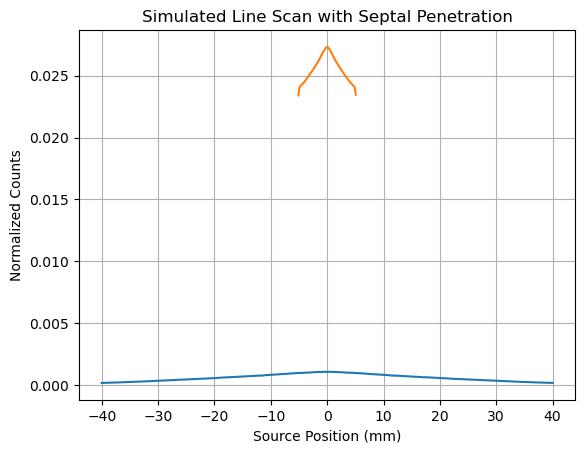

In [51]:
print(len(x_scan))
print(len(transmission))


plt.plot(x_scan, transmission)
plt.plot(convolvedX, convolvedSignal)
plt.title("Simulated Line Scan with Septal Penetration")
plt.xlabel("Source Position (mm)")
plt.ylabel("Normalized Counts")
plt.grid(True)
plt.show()